# Lab 11. Hidden Markov Models and Regime Switching

[Open this lab in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MachineLearning2sda/blob/main/labs/chapter-11-hidden-markov-regime-switching-lab.ipynb)

This lab is designed for independent study. It explains the statistical ideas before programming. You will implement the main algorithms from scratch rather than treating them as black boxes.

## Learning goals

By the end of this lab, you should be able to:

1. Explain the difference between an observed time series and a hidden-state sequence.
2. Simulate a two-state Gaussian Hidden Markov Model.
3. Compute filtering probabilities with the forward algorithm.
4. Decode the most likely hidden-state path with the Viterbi algorithm.
5. Compute smoothed state probabilities with the forward-backward algorithm.
6. Estimate a Gaussian HMM using the Baum-Welch EM algorithm.
7. Produce a one-step-ahead predictive distribution.
8. Explain how HMMs connect to regime-switching time-series models.

The notebook avoids LaTeX commands that often render poorly in Google Colab.

## 1. Background: why hidden states?

In many time-series problems, the behavior of the observed sequence changes over time. A financial return series may alternate between calm and volatile periods. A sensor may alternate between normal and abnormal operation. A biological signal may alternate between latent activity states.

A Hidden Markov Model, or HMM, assumes that there is an unobserved state sequence

$$
z_t \in \{0,1,\ldots,K-1\}
$$

and an observed sequence $y_t$. The hidden state controls the distribution of the observation.

An HMM has three ingredients:

1. Initial probabilities:

$$
\pi_k = P(z_0=k).
$$

2. Transition probabilities:

$$
A_{ij}=P(z_t=j \mid z_{t-1}=i).
$$

3. Emission distributions:

$$
y_t \mid z_t=k \sim f_k(y).
$$

In a Gaussian HMM,

$$
y_t \mid z_t=k \sim N(\mu_k,\sigma_k^2).
$$

The hidden states are Markov:

$$
P(z_t \mid z_{0:t-1})=P(z_t \mid z_{t-1}).
$$

The observations are conditionally independent given the hidden states:

$$
P(y_t \mid z_{0:t},y_{0:t-1})=P(y_t \mid z_t).
$$

These assumptions lead to efficient dynamic-programming algorithms.

## 2. Imports

We will use standard scientific Python. The HMM algorithms are implemented directly so you can see the probability recursions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(7339)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

## 3. Simulate a two-state Gaussian HMM

We begin with a known model. This lets us check whether our algorithms recover the hidden structure.

Use two states:

- state 0: lower mean and lower variance,
- state 1: higher mean and higher variance.

The transition matrix is

$$
A=\begin{pmatrix}
0.96 & 0.04 \\
0.08 & 0.92
\end{pmatrix}.
$$

The large diagonal entries mean that regimes tend to persist.

In [2]:
def simulate_gaussian_hmm(n, pi, A, means, sigmas, rng):
    # Simulate hidden states z_t and observations y_t from a Gaussian HMM.
    K = len(pi)
    z = np.zeros(n, dtype=int)
    y = np.zeros(n)

    z[0] = rng.choice(K, p=pi)
    y[0] = rng.normal(means[z[0]], sigmas[z[0]])

    for t in range(1, n):
        z[t] = rng.choice(K, p=A[z[t - 1]])
        y[t] = rng.normal(means[z[t]], sigmas[z[t]])

    return z, y

n = 350
pi_true = np.array([0.70, 0.30])
A_true = np.array([
    [0.96, 0.04],
    [0.08, 0.92]
])
means_true = np.array([-1.0, 1.2])
sigmas_true = np.array([0.35, 0.75])

z_true, y = simulate_gaussian_hmm(n, pi_true, A_true, means_true, sigmas_true, rng)

df = pd.DataFrame({"time": np.arange(n), "y": y, "hidden_state": z_true})
df.head()

,time,y,hidden_state
0,0,-1.186253,0
1,1,-0.762625,0
2,2,-1.318690,0
3,3,-1.341556,0
4,4,-1.232045,0


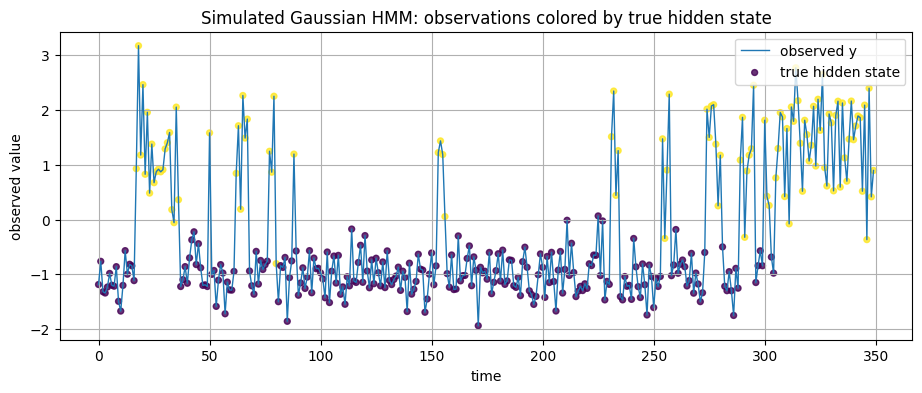

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["time"], df["y"], linewidth=1, label="observed y")
ax.scatter(df["time"], df["y"], c=df["hidden_state"], s=18, alpha=0.8, label="true hidden state")
ax.set_title("Simulated Gaussian HMM: observations colored by true hidden state")
ax.set_xlabel("time")
ax.set_ylabel("observed value")
ax.legend(loc="upper right")
plt.show()

### Interpretation checkpoint

Look at the plot. Some points strongly suggest one state, but many are ambiguous. HMMs use both the current observation and the persistence of regimes. A single observation may be unclear, but a sequence of observations can provide stronger evidence.

## 4. Emission likelihoods

The algorithms need the emission likelihood matrix

$$
B_{tk}=f_k(y_t).
$$

For a Gaussian HMM,

$$
B_{tk}=\frac{1}{\sqrt{2\pi}\sigma_k}\exp\left[-\frac{1}{2}\left(\frac{y_t-\mu_k}{\sigma_k}\right)^2\right].
$$

In [4]:
def gaussian_emission_matrix(y, means, sigmas):
    # Return B[t, k] = density of y[t] under state k.
    y = np.asarray(y)
    K = len(means)
    B = np.zeros((len(y), K))
    for k in range(K):
        B[:, k] = norm.pdf(y, loc=means[k], scale=sigmas[k])
    return B

B_true = gaussian_emission_matrix(y, means_true, sigmas_true)
pd.DataFrame(B_true[:5], columns=["state 0 likelihood", "state 1 likelihood"])

,state 0 likelihood,state 1 likelihood
0,0.989349,0.003370
1,0.905648,0.017333
2,0.753023,0.001892
3,0.708020,0.001707
4,0.914944,0.002770


## 5. Filtering with the scaled forward algorithm

Filtering computes the probability of the current hidden state after seeing data up to the current time:

$$
\alpha_t(k)=P(z_t=k \mid y_0,\ldots,y_t).
$$

The unnormalized recursion is

$$
\tilde{\alpha}_0(k)=\pi_k B_{0k},
$$

$$
\tilde{\alpha}_t(k)=B_{tk}\sum_i \alpha_{t-1}(i)A_{ik}.
$$

We normalize each row to avoid numerical underflow.

In [5]:
def forward_scaled(y, pi, A, means, sigmas):
    # Scaled forward algorithm for a Gaussian HMM.
    B = gaussian_emission_matrix(y, means, sigmas)
    n, K = B.shape
    alpha = np.zeros((n, K))
    scales = np.zeros(n)

    unnormalized = pi * B[0]
    scales[0] = unnormalized.sum()
    alpha[0] = unnormalized / scales[0]

    for t in range(1, n):
        unnormalized = B[t] * (alpha[t - 1] @ A)
        scales[t] = unnormalized.sum()
        alpha[t] = unnormalized / scales[t]

    loglik = np.sum(np.log(scales))
    return alpha, scales, loglik, B

alpha_true, scales_true, loglik_true, B_true = forward_scaled(
    y, pi_true, A_true, means_true, sigmas_true
)

print("Log likelihood under true parameters:", round(loglik_true, 2))
pd.DataFrame(alpha_true[:5], columns=["P(state 0 | data so far)", "P(state 1 | data so far)"])

Log likelihood under true parameters: -284.99


,P(state 0 | data so far),P(state 1 | data so far)
0,0.998542,0.001458
1,0.999177,0.000823
2,0.999893,0.000107
3,0.999899,0.000101
4,0.999874,0.000126


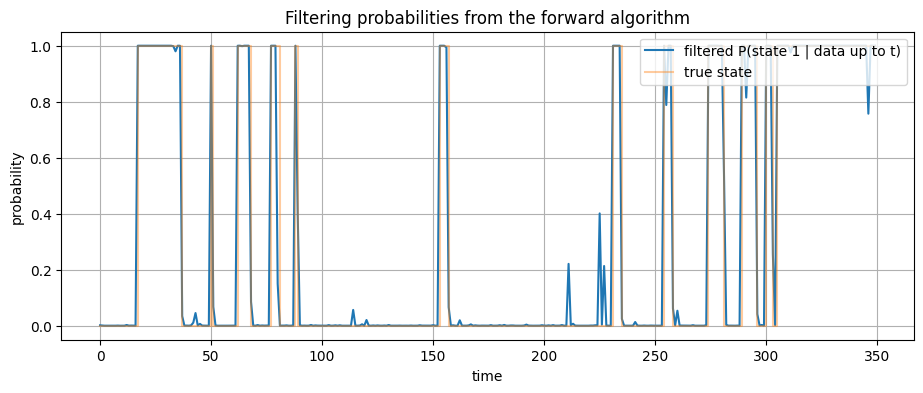

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(alpha_true[:, 1], label="filtered P(state 1 | data up to t)")
ax.plot(z_true, alpha=0.4, label="true state", drawstyle="steps-post")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Filtering probabilities from the forward algorithm")
ax.set_xlabel("time")
ax.set_ylabel("probability")
ax.legend(loc="upper right")
plt.show()

### Interpretation checkpoint

The filtered probability combines observation evidence with transition persistence. When the observation is ambiguous, the previous state belief has strong influence.

## 6. Viterbi decoding

Filtering gives probabilities. Sometimes we want one most likely hidden-state path:

$$
\hat z_{0:n-1}=\arg\max_{z_{0:n-1}}P(z_{0:n-1}\mid y_{0:n-1}).
$$

The Viterbi algorithm computes this path efficiently using dynamic programming. We use log probabilities to avoid underflow.

In [7]:
def viterbi_gaussian(y, pi, A, means, sigmas):
    # Viterbi decoding for a Gaussian HMM.
    y = np.asarray(y)
    n = len(y)
    K = len(pi)

    log_pi = np.log(pi + 1e-300)
    log_A = np.log(A + 1e-300)
    log_B = np.zeros((n, K))
    for k in range(K):
        log_B[:, k] = norm.logpdf(y, loc=means[k], scale=sigmas[k])

    delta = np.zeros((n, K))
    backptr = np.zeros((n, K), dtype=int)
    delta[0] = log_pi + log_B[0]

    for t in range(1, n):
        for k in range(K):
            scores = delta[t - 1] + log_A[:, k]
            backptr[t, k] = np.argmax(scores)
            delta[t, k] = scores[backptr[t, k]] + log_B[t, k]

    z_hat = np.zeros(n, dtype=int)
    z_hat[-1] = np.argmax(delta[-1])
    for t in range(n - 2, -1, -1):
        z_hat[t] = backptr[t + 1, z_hat[t + 1]]

    return z_hat, delta

z_vit, delta = viterbi_gaussian(y, pi_true, A_true, means_true, sigmas_true)
accuracy = np.mean(z_vit == z_true)
print("Viterbi path accuracy using true parameters:", round(accuracy, 3))

Viterbi path accuracy using true parameters: 0.997


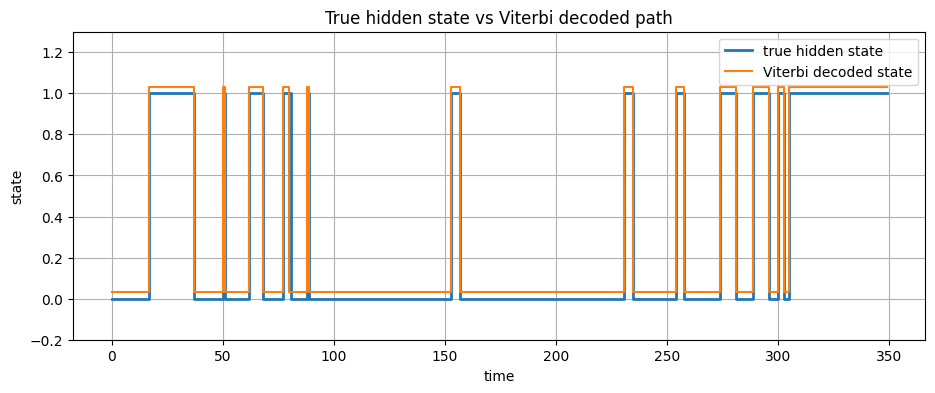

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(z_true, drawstyle="steps-post", linewidth=2, label="true hidden state")
ax.plot(z_vit + 0.03, drawstyle="steps-post", linewidth=1.5, label="Viterbi decoded state")
ax.set_ylim(-0.2, 1.3)
ax.set_title("True hidden state vs Viterbi decoded path")
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.legend(loc="upper right")
plt.show()

### Interpretation checkpoint

Even with the true parameters, Viterbi decoding is not perfect because the observations are noisy. The goal is the most probable state path given the model and data.

## 7. Smoothing with the forward-backward algorithm

Filtering uses observations up to time $t$. Smoothing uses the entire observed sequence:

$$
\gamma_t(k)=P(z_t=k \mid y_0,\ldots,y_{n-1}).
$$

The backward recursion is

$$
\beta_{n-1}(k)=1,
$$

$$
\beta_t(i)=\frac{\sum_j A_{ij}B_{t+1,j}\beta_{t+1}(j)}{c_{t+1}},
$$

where $c_t$ is the forward scaling constant. Then

$$
\gamma_t(k)\propto \alpha_t(k)\beta_t(k).
$$

In [9]:
def forward_backward_scaled(y, pi, A, means, sigmas):
    # Return filtering alpha, backward beta, smoothing gamma, and log likelihood.
    alpha, scales, loglik, B = forward_scaled(y, pi, A, means, sigmas)
    n, K = alpha.shape

    beta = np.ones((n, K))
    for t in range(n - 2, -1, -1):
        beta[t] = (A @ (B[t + 1] * beta[t + 1])) / scales[t + 1]

    gamma = alpha * beta
    gamma = gamma / gamma.sum(axis=1, keepdims=True)
    return alpha, beta, gamma, loglik, B, scales

alpha_true, beta_true, gamma_true, loglik_true, B_true, scales_true = forward_backward_scaled(
    y, pi_true, A_true, means_true, sigmas_true
)

pd.DataFrame(gamma_true[:5], columns=["P(state 0 | all data)", "P(state 1 | all data)"])

,P(state 0 | all data),P(state 1 | all data)
0,0.999876,0.000124
1,0.999931,0.000069
2,0.999991,0.000009
3,0.999992,0.000008
4,0.999989,0.000011


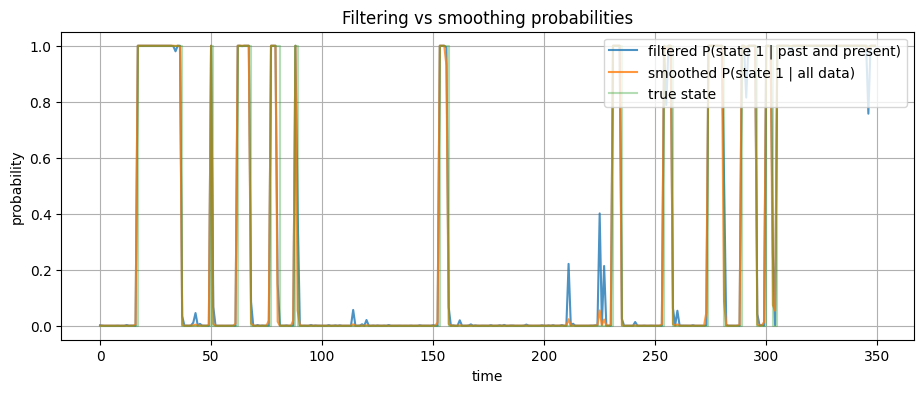

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(alpha_true[:, 1], label="filtered P(state 1 | past and present)", alpha=0.8)
ax.plot(gamma_true[:, 1], label="smoothed P(state 1 | all data)", alpha=0.8)
ax.plot(z_true, label="true state", alpha=0.35, drawstyle="steps-post")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Filtering vs smoothing probabilities")
ax.set_xlabel("time")
ax.set_ylabel("probability")
ax.legend(loc="upper right")
plt.show()

### Interpretation checkpoint

Filtering is useful for online forecasting. Smoothing is useful for historical regime interpretation after the full sequence is observed.

## 8. Baum-Welch EM for a Gaussian HMM

In applications the parameters are unknown. Baum-Welch is the EM algorithm for HMMs.

### E-step

Compute

$$
\gamma_t(k)=P(z_t=k \mid y_{0:n-1})
$$

and

$$
\xi_t(i,j)=P(z_t=i,z_{t+1}=j \mid y_{0:n-1}).
$$

### M-step

Update expected counts:

$$
\pi_k^{new}=\gamma_0(k),
$$

$$
A_{ij}^{new}=\frac{\sum_{t=0}^{n-2}\xi_t(i,j)}{\sum_{t=0}^{n-2}\gamma_t(i)}.
$$

For Gaussian emissions:

$$
\mu_k^{new}=\frac{\sum_t \gamma_t(k)y_t}{\sum_t \gamma_t(k)},
$$

$$
(\sigma_k^2)^{new}=\frac{\sum_t \gamma_t(k)(y_t-\mu_k^{new})^2}{\sum_t \gamma_t(k)}.
$$

In [11]:
def compute_xi(y, A, B, alpha, beta, scales):
    # Compute xi[t, i, j] = P(z_t=i, z_{t+1}=j | all observations).
    n, K = alpha.shape
    xi = np.zeros((n - 1, K, K))

    for t in range(n - 1):
        numerator = alpha[t, :, None] * A * (B[t + 1] * beta[t + 1])[None, :]
        denominator = numerator.sum()
        xi[t] = numerator / denominator

    return xi


def baum_welch_gaussian(y, K=2, n_iter=50):
    # Educational implementation of Baum-Welch for Gaussian emissions.
    y = np.asarray(y)

    means = np.quantile(y, np.linspace(0.15, 0.85, K))
    sigmas = np.repeat(np.std(y), K)

    A = np.full((K, K), 0.10 / (K - 1))
    np.fill_diagonal(A, 0.90)
    pi = np.ones(K) / K

    loglik_history = []

    for iteration in range(n_iter):
        alpha, beta, gamma, loglik, B, scales = forward_backward_scaled(y, pi, A, means, sigmas)
        xi = compute_xi(y, A, B, alpha, beta, scales)

        pi = gamma[0]
        A = xi.sum(axis=0) / gamma[:-1].sum(axis=0)[:, None]

        weights = gamma.sum(axis=0)
        means = (gamma * y[:, None]).sum(axis=0) / weights
        variances = (gamma * (y[:, None] - means[None, :])**2).sum(axis=0) / weights
        sigmas = np.sqrt(np.maximum(variances, 1e-6))
        loglik_history.append(loglik)

    return {
        "pi": pi,
        "A": A,
        "means": means,
        "sigmas": sigmas,
        "loglik_history": np.array(loglik_history),
        "gamma": gamma,
        "alpha": alpha,
    }

fit = baum_welch_gaussian(y, K=2, n_iter=50)

print("Estimated initial probabilities:")
print(np.round(fit["pi"], 3))
print("\nEstimated transition matrix:")
print(np.round(fit["A"], 3))
print("\nEstimated means:")
print(np.round(fit["means"], 3))
print("\nEstimated sigmas:")
print(np.round(fit["sigmas"], 3))

Estimated initial probabilities:
[1. 0.]

Estimated transition matrix:
[[0.95  0.05 ]
 [0.108 0.892]]

Estimated means:
[-1.016  1.318]

Estimated sigmas:
[0.338 0.745]


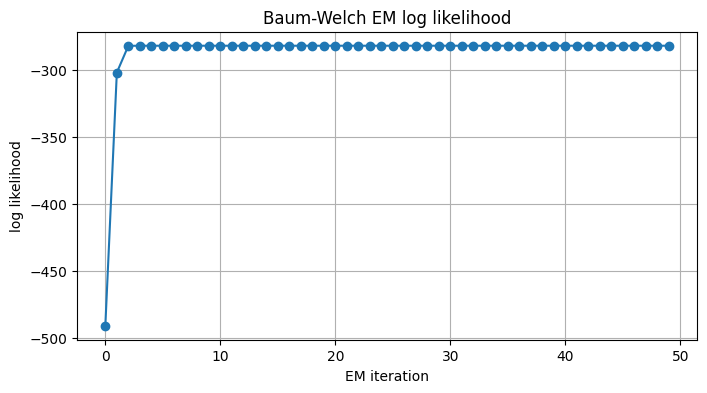

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fit["loglik_history"], marker="o")
ax.set_title("Baum-Welch EM log likelihood")
ax.set_xlabel("EM iteration")
ax.set_ylabel("log likelihood")
plt.show()

### Label switching

The labels "state 0" and "state 1" have no intrinsic meaning. If we swap all state labels, the likelihood is unchanged. This is called label switching. For interpretation, we often sort fitted states by estimated mean or variance.

In [13]:
order = np.argsort(fit["means"])
means_sorted = fit["means"][order]
sigmas_sorted = fit["sigmas"][order]
A_sorted = fit["A"][order][:, order]
gamma_sorted = fit["gamma"][:, order]
alpha_sorted = fit["alpha"][:, order]

print("True means:       ", means_true)
print("Estimated means:  ", np.round(means_sorted, 3))
print("\nTrue sigmas:       ", sigmas_true)
print("Estimated sigmas:  ", np.round(sigmas_sorted, 3))
print("\nTrue transition matrix:")
print(A_true)
print("\nEstimated transition matrix after sorting:")
print(np.round(A_sorted, 3))

True means:        [-1.   1.2]
Estimated means:   [-1.016  1.318]

True sigmas:        [0.35 0.75]
Estimated sigmas:   [0.338 0.745]

True transition matrix:
[[0.96 0.04]
 [0.08 0.92]]

Estimated transition matrix after sorting:
[[0.95  0.05 ]
 [0.108 0.892]]


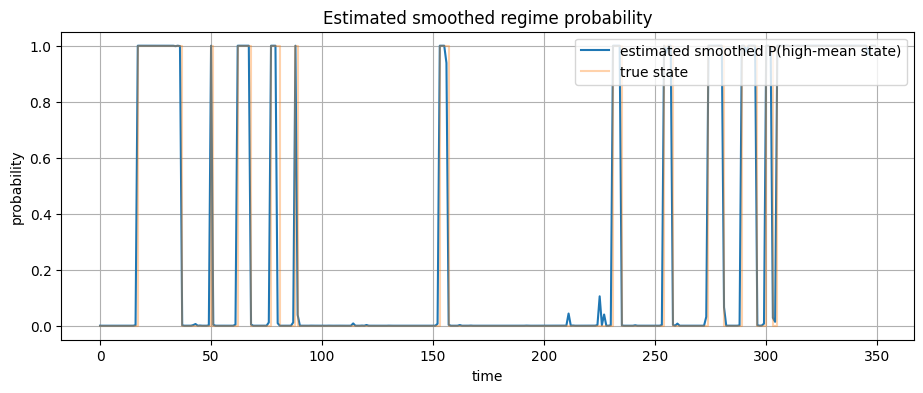

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gamma_sorted[:, 1], label="estimated smoothed P(high-mean state)")
ax.plot(z_true, alpha=0.35, drawstyle="steps-post", label="true state")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Estimated smoothed regime probability")
ax.set_xlabel("time")
ax.set_ylabel("probability")
ax.legend(loc="upper right")
plt.show()

## 9. One-step-ahead forecasting from an HMM

At time $t$, let

$$
p_t(k)=P(z_t=k \mid y_0,\ldots,y_t).
$$

The predicted state probabilities are

$$
p_{t+1|t}=p_t A.
$$

For a Gaussian HMM, the predictive distribution is a mixture of Gaussians:

$$
y_{t+1}\mid y_0,\ldots,y_t \sim \sum_k p_{t+1|t}(k)N(\mu_k,\sigma_k^2).
$$

The predictive mean is

$$
E(y_{t+1}\mid y_0,\ldots,y_t)=\sum_k p_{t+1|t}(k)\mu_k.
$$

In [15]:
def hmm_one_step_forecast(alpha_last, A, means, sigmas):
    # One-step predictive mean and standard deviation for a Gaussian HMM.
    state_prob_next = alpha_last @ A
    pred_mean = np.sum(state_prob_next * means)
    second_moment = np.sum(state_prob_next * (sigmas**2 + means**2))
    pred_var = second_moment - pred_mean**2
    pred_sd = np.sqrt(max(pred_var, 0.0))
    return state_prob_next, pred_mean, pred_sd

state_prob_next, pred_mean, pred_sd = hmm_one_step_forecast(
    alpha_sorted[-1], A_sorted, means_sorted, sigmas_sorted
)

print("Predicted next-state probabilities:", np.round(state_prob_next, 3))
print("One-step predictive mean:", round(pred_mean, 3))
print("One-step predictive standard deviation:", round(pred_sd, 3))
print("Approximate 95% forecast interval:", (round(pred_mean - 1.96 * pred_sd, 3), round(pred_mean + 1.96 * pred_sd, 3)))

Predicted next-state probabilities: [0.108 0.892]
One-step predictive mean: 1.065
One-step predictive standard deviation: 1.016
Approximate 95% forecast interval: (np.float64(-0.927), np.float64(3.057))


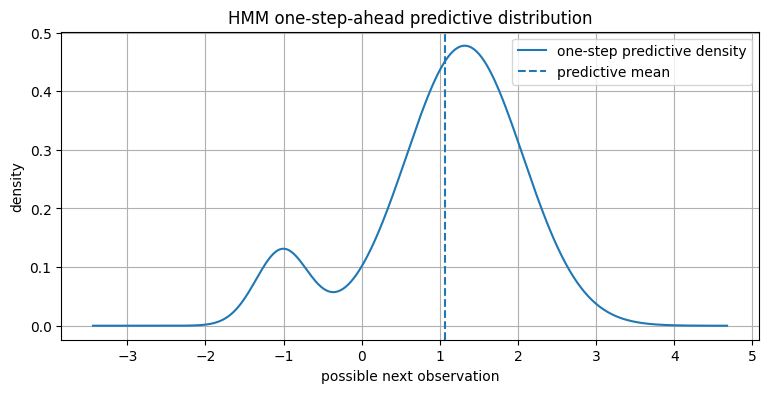

In [16]:
grid = np.linspace(y.min() - 1.5, y.max() + 1.5, 500)
density = np.zeros_like(grid)
for k in range(2):
    density += state_prob_next[k] * norm.pdf(grid, means_sorted[k], sigmas_sorted[k])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grid, density, label="one-step predictive density")
ax.axvline(pred_mean, linestyle="--", label="predictive mean")
ax.set_title("HMM one-step-ahead predictive distribution")
ax.set_xlabel("possible next observation")
ax.set_ylabel("density")
ax.legend()
plt.show()

## 10. Regime-switching autoregression idea

A Gaussian HMM assumes that observations are conditionally independent given the hidden states. A regime-switching autoregressive model lets the time-series dynamics change across states:

$$
y_t=\mu_{z_t}+\phi_{z_t}(y_{t-1}-\mu_{z_t})+\sigma_{z_t}\epsilon_t,
$$

where

$$
\epsilon_t\sim N(0,1).
$$

Now each regime has its own mean, persistence, and noise level.

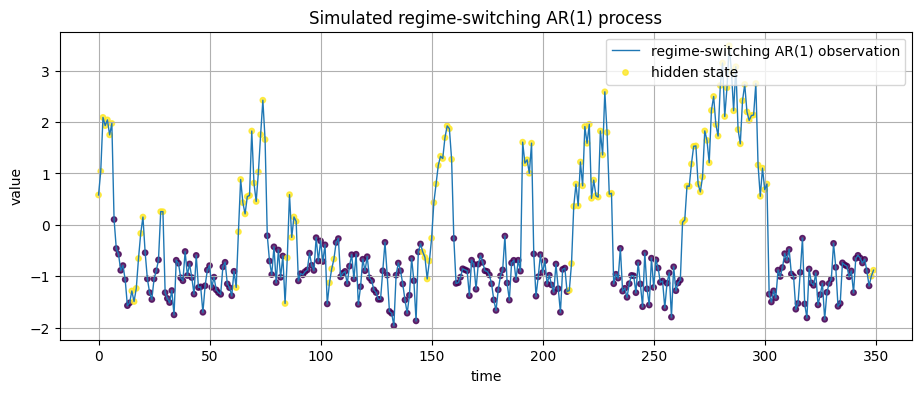

In [17]:
def simulate_regime_switching_ar1(n, pi, A, means, phis, sigmas, rng):
    K = len(pi)
    z = np.zeros(n, dtype=int)
    y = np.zeros(n)

    z[0] = rng.choice(K, p=pi)
    y[0] = rng.normal(means[z[0]], sigmas[z[0]])

    for t in range(1, n):
        z[t] = rng.choice(K, p=A[z[t - 1]])
        k = z[t]
        y[t] = means[k] + phis[k] * (y[t - 1] - means[k]) + sigmas[k] * rng.normal()

    return z, y

phis_rs = np.array([0.20, 0.85])
sigmas_rs = np.array([0.35, 0.55])
z_rs, y_rs = simulate_regime_switching_ar1(
    n=350,
    pi=pi_true,
    A=A_true,
    means=means_true,
    phis=phis_rs,
    sigmas=sigmas_rs,
    rng=rng
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_rs, linewidth=1, label="regime-switching AR(1) observation")
ax.scatter(np.arange(len(y_rs)), y_rs, c=z_rs, s=15, alpha=0.8, label="hidden state")
ax.set_title("Simulated regime-switching AR(1) process")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.legend(loc="upper right")
plt.show()

### Interpretation checkpoint

The regime-switching AR(1) model is closer to classical time-series modeling because it includes dependence on the previous observation. If residuals from a Gaussian HMM still show strong autocorrelation, a regime-switching AR model may be more appropriate.

## 11. Exercises

### Exercise 1: Transition persistence

Change the transition matrix to

$$
A=\begin{pmatrix}
0.80 & 0.20 \\
0.20 & 0.80
\end{pmatrix}.
$$

Simulate a new sequence. Are regimes shorter or longer?

### Exercise 2: Emission overlap

Change the state means to $-0.5$ and $0.5$, keeping the same standard deviations. Does Viterbi decoding become easier or harder?

### Exercise 3: Filtering vs smoothing

Find a time interval where filtering and smoothing differ noticeably. Explain why future observations changed the inferred state probability.

### Exercise 4: EM initialization

Run Baum-Welch with different initial values. Do the fitted parameters always look the same?

### Exercise 5: Forecasting

Use the fitted HMM to compute one-step-ahead predictive means for every time point. Compare them with the observations.

## 12. Mini-projects

### Mini-project A: volatility regimes

Simulate a two-state HMM where both states have mean 0 but different standard deviations. Fit a two-state Gaussian HMM and plot the smoothed probability of the high-volatility state.

### Mini-project B: regime-switching AR process

Simulate a two-state regime-switching AR(1) process. Compute sample ACFs on intervals that appear to be mostly in one state. Explain how dependence changes between regimes.

## 13. AI-assisted study prompts

Use AI as a tutor and critic, not as an unquestioned answer generator.

1. "Explain filtering, smoothing, and Viterbi decoding in a Hidden Markov Model using a time-series example."
2. "I implemented the scaled forward algorithm for a Gaussian HMM. What numerical issues should I check?"
3. "Why can Baum-Welch converge to different answers from different initializations?"
4. "Explain label switching in a two-state Gaussian HMM."
5. "Compare a Gaussian HMM with a regime-switching AR(1) model."

After using AI, verify the explanation by checking the code and plots in this lab.

## 14. Lab checklist

Before finishing, make sure you can:

- Explain what hidden states are.
- Simulate a two-state Gaussian HMM.
- Compute emission likelihoods.
- Implement the scaled forward algorithm.
- Interpret filtering probabilities.
- Implement Viterbi decoding.
- Explain filtering vs smoothing.
- Run Baum-Welch EM for a Gaussian HMM.
- Explain label switching.
- Compute a one-step-ahead predictive distribution.
- Explain the difference between a Gaussian HMM and a regime-switching AR model.